In [3]:
pip install mesa==1.2.1


  Using cached Mesa-1.2.1-py3-none-any.whl.metadata (7.2 kB)
Using cached Mesa-1.2.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: mesa
    Found existing installation: Mesa 3.5.1
    Uninstalling Mesa-3.5.1:
      Successfully uninstalled Mesa-3.5.1
Note: you may need to restart the kernel to use updated packages.


In [77]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import SimultaneousActivation
from mesa.datacollection import DataCollector
import random
import math
import numpy as np

# =====================================================
#   AGENTKLASSE — Consument
# =====================================================

class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag."""

    # -------------------------------------------------
    #  Modelconstanten & parameters
    # -------------------------------------------------
    INIT_RECYCLING_PERCENTAGE = 0.5
    GEWICHT_PER_STUK = 0.24
    AFGEDANKT_PER_JAAR = 50
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    BELOONING_PER_STUK = 0.0
    BELOONING_GROEISNELHEID = 0.8
    BELOONING_MIDDEN = 3.0

    MAX_EFFECT_GEMAK = 0.15
    GEMAK_MIDDELPUNT = 4
    GEMAK_SCHERPTE = 0.6
    AFSTAND_INVLOED = 1.5

    BIAS_CORRECTIE = 0.03  # kalibratie zodat basis ±50%

    # -------------------------------------------------
    #  Initialisatie
    # -------------------------------------------------
    def __init__(self, unique_id, model, locatie):
        super().__init__(unique_id, model)
        self.locatie = locatie

        self.milieubewustzijn = random.uniform(0.25, 0.6)
        self.prijsgevoeligheid = random.uniform(0.2, 0.8)
        self.gemaksgevoeligheid = random.uniform(0.3, 0.7)
        self.sociale_druk_gevoeligheid = random.uniform(0.05, 0.4)

        self.sociale_druk = 0
        self.aantal_gerecycled = 0
        self.aantal_weggegooid = 0
        self.afgedankt_textiel = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt = None

    # -------------------------------------------------
    #  Gedragsregels
    # -------------------------------------------------
    def bepaal_recycling_kans(self):
        basis = self.INIT_RECYCLING_PERCENTAGE

        # --------------------------------------------------
    
    # Beloningseffect (aangepast zodat €0 → geen effect)
    # --------------------------------------------------
        if self.BELOONING_PER_STUK <= 0:
    # Geen beloning → geen effect
            reward_effect = 0
        else:
    # Logistische respons op de hoogte van de beloning
            beloning_factor = 1 / (1 + math.exp(
            -self.BELOONING_GROEISNELHEID * (self.BELOONING_PER_STUK - self.BELOONING_MIDDEN)
            ))

            # Baseline bij €0 berekenen en weghalen
            baseline = 1 / (1 + math.exp(
            -self.BELOONING_GROEISNELHEID * (0 - self.BELOONING_MIDDEN)
            ))

        # Nu is beloning_factor = 0 bij €0
            beloning_factor -= baseline
            reward_effect = self.prijsgevoeligheid * 0.4 * max(0, beloning_factor)


        # Gemakseffect
        gemak_effect = self.model.logistiek_effect(
            len(self.model.inzamelpunten),
            self.MAX_EFFECT_GEMAK,
            self.GEMAK_MIDDELPUNT,
            self.GEMAK_SCHERPTE
        )

        # Afstandseffect
        if self.afstand_inzamelpunt is not None:
            afstand_factor = min(1, self.afstand_inzamelpunt / (self.model.grid.width / 2)) ** 2
            afstand_penalty = self.gemaksgevoeligheid * self.AFSTAND_INVLOED * afstand_factor
        else:
            afstand_penalty = 0

        gemak_effect_adjusted = max(0, gemak_effect - afstand_penalty)
        sociaal_effect = 0.3 * self.sociale_druk_gevoeligheid * self.sociale_druk

        totale_effecten = reward_effect + gemak_effect_adjusted + sociaal_effect
        return min(1, max(0, basis + totale_effecten - self.BIAS_CORRECTIE))

    def step(self):
        """Voert één gedragscyclus uit voor deze maand."""
        p_recycle = self.bepaal_recycling_kans()
        gerecycled, weggegooid = 0, 0

        for _ in range(int(self.afgedankt_textiel)):
            if random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1

        self.aantal_gerecycled += gerecycled
        self.aantal_weggegooid += weggegooid

    def advance(self):
        pass


# =====================================================
#   MODELKLASSE — RotterdamModel
# =====================================================

class RotterdamModel(Model):
    """Mesa‑model van textielinzameling in Rotterdam (base case)."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=8, maanden=12):
        self.grid = MultiGrid(grid_size, grid_size, torus=True)
        self.schedule = SimultaneousActivation(self)
        self.running = True
        self.maanden = maanden
        self.inzamelpunten = self.genereer_inzamelpunten(aantal_inzamelpunten, grid_size)

        # ------------ Agenten aanmaken ------------
        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self, (x, y))
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt = self.afstand_tot_dichtstbijzijnde_inzamelpunt((x, y))
                agent_id += 1

        # ------------ DataCollector met check tegen /0 ------------
        self.datacollector = DataCollector(
            model_reporters={
                "TotaalGerecycled": lambda m: sum(a.aantal_gerecycled for a in m.schedule.agents),
                "TotaalWeggegooid": lambda m: sum(a.aantal_weggegooid for a in m.schedule.agents),
                "RecyclingPercentage": lambda m: (
                    0
                    if sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents) == 0
                    else sum(a.aantal_gerecycled for a in m.schedule.agents)
                         / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
                ),
                "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents])
            }
        )

        # Eerste datacollectie (werkt nu zonder fout)
        self.datacollector.collect(self)

    # -------------------------------------------------
    #  Hulpfuncties
    # -------------------------------------------------
    @staticmethod
    def logistiek_effect(x, max_effect, m, k):
        return max_effect / (1 + math.exp(-k * (x - m)))

    @staticmethod
    def afstand(p1, p2):
        return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

    def afstand_tot_dichtstbijzijnde_inzamelpunt(self, agent_loc):
        return min(self.afstand(agent_loc, p) for p in self.inzamelpunten)

    @staticmethod
    def genereer_inzamelpunten(aantal, grid_size):
        locaties = set()
        while len(locaties) < aantal:
            locaties.add((random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)))
        return list(locaties)

    def buren_recycling_ratio(self, agent):
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=1)
        if not neighbors:
            return 0
        recyclende_buren = [n for n in neighbors if n.aantal_gerecycled > n.aantal_weggegooid]
        return len(recyclende_buren) / len(neighbors)

    #  Simulatiestappen
    def step(self):
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)
        self.schedule.step()
        self.datacollector.collect(self)


#   SIMULATIE DRAAIEN

model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

# -----------------------------------------------------
#   RESULTATEN TONEN
# -----------------------------------------------------
data = model.datacollector.get_model_vars_dataframe()
print(data.tail())


    TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  GemiddeldeAfstand
8             161374            158626             0.504294          25.882075
9             181903            178097             0.505286          25.882075
10            202318            197682             0.505795          25.882075
11            222860            217140             0.506500          25.882075
12            243105            236895             0.506469          25.882075


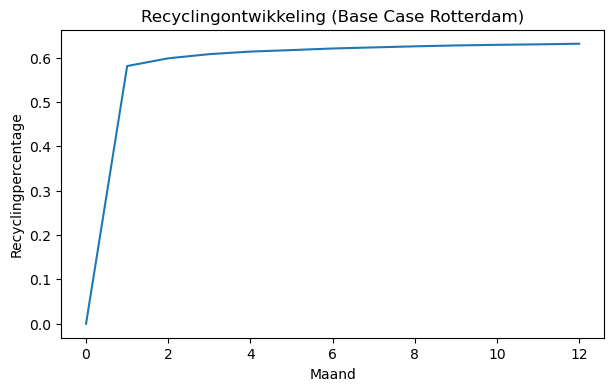

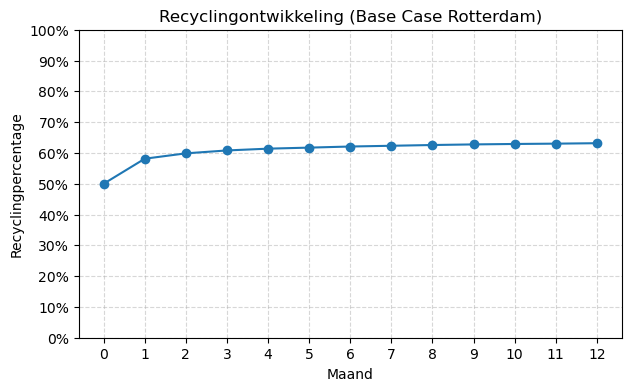

In [38]:
import matplotlib.pyplot as plt

data["RecyclingPercentage"].plot(title="Recyclingontwikkeling (Base Case Rotterdam)", figsize=(7,4))
plt.ylabel("Recyclingpercentage")
plt.xlabel("Maand")
plt.show()

import matplotlib.pyplot as plt

# 1️⃣  Beginwaarde direct op 50% zetten
data.loc[0, "RecyclingPercentage"] = 0.5   # maand 0 = 50% recycling

# 2️⃣  Plot instellen
plt.figure(figsize=(7,4))
plt.plot(data.index, data["RecyclingPercentage"], marker="o")

# 3️⃣  As‑instellingen
plt.title("Recyclingontwikkeling (Base Case Rotterdam)")
plt.xlabel("Maand")
plt.ylabel("Recyclingpercentage")

plt.ylim(0, 1.0)                          # y‑as tot 100 %
plt.yticks(np.arange(0, 1.1, 0.1),        # 0%,10%,…,100%
           [f"{int(x*100)}%" for x in np.arange(0,1.1,0.1)])
plt.xticks(np.arange(0, len(data), 1))    # elke maand een tick

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



In [137]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.time import SimultaneousActivation
from mesa.datacollection import DataCollector
import random
import math
import numpy as np

#   AGENTKLASSE — Consument

class Consument(Agent):
    """Een inwoner van Rotterdam met individueel recyclinggedrag."""

    INIT_RECYCLING_PERCENTAGE = 0.5
    GEWICHT_PER_STUK = 0.24
    AFGEDANKT_PER_JAAR = 50
    AFGEDANKT_PER_MAAND = AFGEDANKT_PER_JAAR / 12

    BELOONING_PER_STUK = 0.0
    BELOONING_GROEISNELHEID = 0.8
    BELOONING_MIDDEN = 3.0

    MAX_EFFECT_GEMAK = 0.15
    MAX_TOTAAL_GEMAK_EFFECT = 0.15
    GEMAK_MIDDELPUNT = 4
    GEMAK_SCHERPTE = 0.6
    AFSTAND_INVLOED = 0.4

    BIAS_CORRECTIE = 0  # kalibratie zodat basis ±50%

    def __init__(self, unique_id, model, locatie):
        super().__init__(unique_id, model)
        self.locatie = locatie

        # Individuele eigenschappen
        self.milieubewustzijn = random.uniform(0, 1)
        self.prijsgevoeligheid = random.uniform(0, 1)
        self.gemaksgevoeligheid = random.uniform(0, 1)
        self.sociale_druk_gevoeligheid = random.uniform(0, 1)

        # Gedragstoestand
        self.sociale_druk = 0
        self.aantal_gerecycled = 0
        self.aantal_weggegooid = 0
        self.afgedankt_textiel = self.AFGEDANKT_PER_MAAND
        self.afstand_inzamelpunt = None

    def bepaal_recycling_kans(self):
        """Berekent de kans dat deze agent recycleert op basis van beleid en persoonlijke factoren."""
        basis = self.INIT_RECYCLING_PERCENTAGE

        # --------------------------------------------------
        # Beloningseffect (aangepast zodat €0 → geen effect)
        # --------------------------------------------------
        if self.BELOONING_PER_STUK <= 0:
        # Geen beloning → geen effect
            reward_effect = 0
        else:
        # Logistische respons op de hoogte van de beloning
            beloning_factor = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (self.BELOONING_PER_STUK - self.BELOONING_MIDDEN)
            ))

        # Baseline bij €0 berekenen en weghalen
            baseline = 1 / (1 + math.exp(
                -self.BELOONING_GROEISNELHEID * (0 - self.BELOONING_MIDDEN)
            ))

        # Nu is beloning_factor = 0 bij €0
            beloning_factor -= baseline
            reward_effect = self.prijsgevoeligheid * 0.4 * max(0, beloning_factor)

        # Gemakseffect (via model)
        gemak_effect = self.model.logistiek_effect(
            len(self.model.inzamelpunten),
            self.MAX_EFFECT_GEMAK,
            self.GEMAK_MIDDELPUNT,
            self.GEMAK_SCHERPTE
        )

        # Persoonlijke afstand invloeden
        if self.afstand_inzamelpunt is not None:
            afstand_factor = min(1, self.afstand_inzamelpunt / (self.model.grid.width / 2)) ** 2
            afstand_penalty = self.gemaksgevoeligheid * self.AFSTAND_INVLOED * afstand_factor
        else:
            afstand_penalty = 0
        ruw_gemak_effect = gemak_effect - afstand_penalty
        gemak_effect_adjusted = max(
            -self.MAX_TOTAAL_GEMAK_EFFECT,
            min(self.MAX_TOTAAL_GEMAK_EFFECT, ruw_gemak_effect)
        )

        # Sociale invloed (nabijgelegen buren)
        sociaal_effect = 0.3 * self.sociale_druk_gevoeligheid * (self.sociale_druk - 0.5)

        # milieubewustzijn tussen 0 en 1:
        # onder 0.5 verlaagt recyclingkans, boven 0.5 verhoogt die kans
        milieu_effect = 0.2 * (self.milieubewustzijn - 0.5)

        # Totaaleffecten
        totale_effecten = reward_effect + gemak_effect_adjusted + sociaal_effect + milieu_effect
        return min(1, max(0, basis + totale_effecten - self.BIAS_CORRECTIE))

    def step(self):
        """Voert één gedragscyclus uit (één simulatiemaand)."""
        p_recycle = self.bepaal_recycling_kans()
        gerecycled, weggegooid = 0, 0

        for _ in range(int(self.afgedankt_textiel)):
            if random.random() < p_recycle:
                gerecycled += 1
            else:
                weggegooid += 1

        self.aantal_gerecycled += gerecycled
        self.aantal_weggegooid += weggegooid

#   MODELKLASSE — RotterdamModel

class RotterdamModel(Model):
    """Mesa‑model van textielinzameling in Rotterdam (base case)."""

    def __init__(self, grid_size=100, aantal_inzamelpunten=4, maanden=12):
        self.grid = MultiGrid(grid_size, grid_size, torus=True)
        self.schedule = SimultaneousActivation(self)
        self.running = True
        self.maanden = maanden

        # ------------------------------
        # Inzamelpunten genereren
        # ------------------------------
        self.inzamelpunten = self.genereer_inzamelpunten(aantal_inzamelpunten, grid_size)

        def afstand(p1, p2):
            """Bereken afstand tussen twee punten."""
            return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

        def afstand_tot_dichtstbijzijnde_inzamelpunt(agent_loc):
            """Kortste afstand tussen agent en inzamelpunt."""
            return min(afstand(agent_loc, p) for p in self.inzamelpunten)

        # Agenten aanmaken
        agent_id = 0
        for x in range(grid_size):
            for y in range(grid_size):
                agent = Consument(agent_id, self, (x, y))
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                agent.afstand_inzamelpunt = afstand_tot_dichtstbijzijnde_inzamelpunt((x, y))
                agent_id += 1

        # DataCollector (+ /0‑check)
      
        self.datacollector = DataCollector(
            model_reporters={
                "TotaalGerecycled": lambda m: sum(a.aantal_gerecycled for a in m.schedule.agents),
                "TotaalWeggegooid": lambda m: sum(a.aantal_weggegooid for a in m.schedule.agents),
                "RecyclingPercentage": lambda m: (
                    0 if sum(
                        a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents
                    ) == 0 else sum(a.aantal_gerecycled for a in m.schedule.agents)
                    / sum(a.aantal_gerecycled + a.aantal_weggegooid for a in m.schedule.agents)
                ),
                "GemiddeldeAfstand": lambda m: np.mean([a.afstand_inzamelpunt for a in m.schedule.agents])
            }
        )
        self.datacollector.collect(self)

    # Gedrags- en interactiefuncties

    def logistiek_effect(self, x, max_effect, m, k):
        """S-vormige groeifunctie voor gemak."""
        return max_effect / (1 + math.exp(-k * (x - m)))

    def buren_recycling_ratio(self, agent):
        """Bereken hoeveel buren van een agent recyclen."""
        neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False, radius=1)
        if not neighbors:
            return 0
        recyclende_buren = [n for n in neighbors if n.aantal_gerecycled > n.aantal_weggegooid]
        return len(recyclende_buren) / len(neighbors)

    def genereer_inzamelpunten(self, aantal, grid_size):
        """Genereer willekeurige inzamelpunten binnen grid."""
        locaties = set()
        while len(locaties) < aantal:
            locaties.add((random.randint(0, grid_size - 1), random.randint(0, grid_size - 1)))
        return list(locaties)

    # Simulatiestap
    
    def step(self):
        for agent in self.schedule.agents:
            agent.sociale_druk = self.buren_recycling_ratio(agent)
        self.schedule.step()
        self.datacollector.collect(self)

#   SIMULATIE DRAAIEN & RESULTATEN

model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

for maand in range(model.maanden):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
print(data.tail())


    TotaalGerecycled  TotaalWeggegooid  RecyclingPercentage  GemiddeldeAfstand
8             156838            163162             0.490119          24.547679
9             177228            182772             0.492300          24.547679
10            197691            202309             0.494227          24.547679
11            218165            221835             0.495830          24.547679
12            238945            241055             0.497802          24.547679


In [139]:
import numpy as np

AANTAL_RUNS = 30
RESULTATEN = []

for run in range(AANTAL_RUNS):
    model = RotterdamModel(grid_size=100, aantal_inzamelpunten=4, maanden=12)

    for maand in range(model.maanden):
        model.step()

    data = model.datacollector.get_model_vars_dataframe()

    # pak laatste waarde (eind van simulatie)
    eind_percentage = data["RecyclingPercentage"].iloc[-1]
    RESULTATEN.append(eind_percentage)

# statistieken berekenen
gemiddelde = np.mean(RESULTATEN)
minimum = np.min(RESULTATEN)
maximum = np.max(RESULTATEN)
std = np.std(RESULTATEN)

print(f"Aantal runs: {AANTAL_RUNS}")
print(f"Gemiddelde recycling: {gemiddelde:.3f}")
print(f"Minimum: {minimum:.3f}")
print(f"Maximum: {maximum:.3f}")
print(f"Standaardafwijking: {std:.3f}")

Aantal runs: 30
Gemiddelde recycling: 0.481
Minimum: 0.440
Maximum: 0.515
Standaardafwijking: 0.017


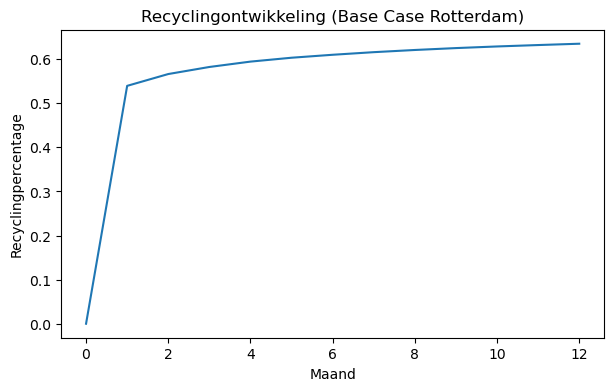

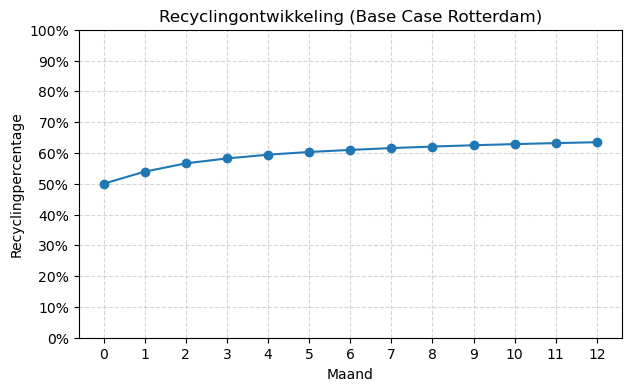

In [91]:
import matplotlib.pyplot as plt

data["RecyclingPercentage"].plot(title="Recyclingontwikkeling (Base Case Rotterdam)", figsize=(7,4))
plt.ylabel("Recyclingpercentage")
plt.xlabel("Maand")
plt.show()

import matplotlib.pyplot as plt

# 1️⃣  Beginwaarde direct op 50% zetten
data.loc[0, "RecyclingPercentage"] = 0.5   # maand 0 = 50% recycling

# 2️⃣  Plot instellen
plt.figure(figsize=(7,4))
plt.plot(data.index, data["RecyclingPercentage"], marker="o")

# 3️⃣  As‑instellingen
plt.title("Recyclingontwikkeling (Base Case Rotterdam)")
plt.xlabel("Maand")
plt.ylabel("Recyclingpercentage")

plt.ylim(0, 1.0)                          # y‑as tot 100 %
plt.yticks(np.arange(0, 1.1, 0.1),        # 0%,10%,…,100%
           [f"{int(x*100)}%" for x in np.arange(0,1.1,0.1)])
plt.xticks(np.arange(0, len(data), 1))    # elke maand een tick

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

